In [22]:
import os
import sys
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

In [24]:
token = os.getenv('IBM_QUANTUM_KEY')
if not token:
	print("API KEY needed, please add it in your environment before continuing")
	sys.exit(os.EX_CONFIG)

In [18]:
qc = QuantumCircuit(2)

qc.h([0])
qc.cx(0, 1)
qc.measure_all()

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Connexion
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=token)
backend = service.least_busy(simulator=False, operational=True)

# Adaptation (portes logique = instruction QPU)
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Envoi
sampler = SamplerV2(backend)
job = sampler.run([isa_circuit])

qiskit_runtime_service._discover_account:WARNING:2026-04-26 10:09:19,253: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-26 10:09:21,912: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-26 10:09:22,585: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-26 10:09:25,427: Using instance: open-instance, plan: open


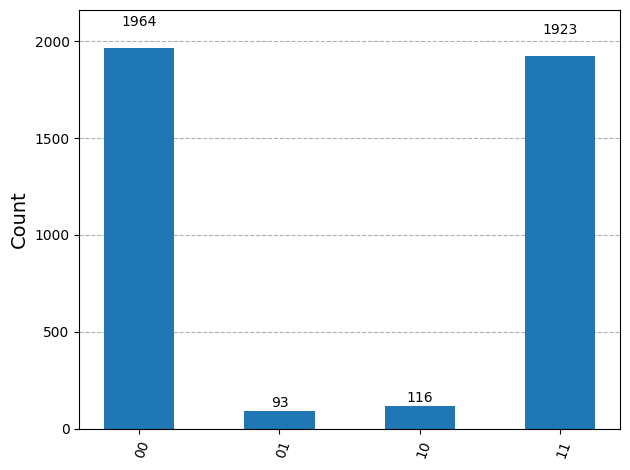

In [23]:
result = job.result()
pub_result = result[0]

counts = pub_result.data.meas.get_counts()
plot_histogram(counts)